<a href="https://colab.research.google.com/github/amandeshmukh08/Hospital-readmission-analysis-python/blob/main/Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving hospital.csv to hospital.csv


In [4]:
df = pd.read_csv("hospital.csv")

In [5]:
# First 5 Rows

df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [6]:
# Number of Rows and Columns

df.shape

(30000, 12)

In [7]:
df.columns.tolist()

['patient_id',
 'age',
 'gender',
 'blood_pressure',
 'cholesterol',
 'bmi',
 'diabetes',
 'hypertension',
 'medication_count',
 'length_of_stay',
 'discharge_destination',
 'readmitted_30_days']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [9]:
df.describe(include="all")

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
count,30000.000000,30000.000000,30000,30000,30000.000000,30000.000000,30000,30000,30000.000000,30000.000000,30000,30000
unique,NaN,NaN,3,1581,NaN,NaN,2,2,NaN,NaN,3,2
top,NaN,NaN,Male,143/94,NaN,NaN,No,No,NaN,NaN,Home,No
freq,NaN,NaN,10097,41,NaN,NaN,15051,15022,NaN,NaN,20877,26326
mean,15000.500000,53.884233,NaN,NaN,225.260400,28.946263,NaN,NaN,5.012267,5.502900,NaN,NaN
std,8660.398374,21.056485,NaN,NaN,43.585671,6.348204,NaN,NaN,3.166383,2.867298,NaN,NaN
min,1.000000,18.000000,NaN,NaN,150.000000,18.000000,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,7500.750000,36.000000,NaN,NaN,188.000000,23.400000,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,15000.500000,54.000000,NaN,NaN,225.000000,28.900000,NaN,NaN,5.000000,5.000000,NaN,NaN
75%,22500.250000,72.000000,NaN,NaN,263.000000,34.500000,NaN,NaN,8.000000,8.000000,NaN,NaN


In [10]:
df.sample(5)

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
9311,9312,57,Male,157/83,241,27.4,No,No,9,9,Nursing_Facility,No
1324,1325,32,Female,115/96,171,24.1,Yes,No,8,9,Nursing_Facility,Yes
1621,1622,78,Other,118/72,275,23.0,Yes,Yes,3,7,Home,Yes
10286,10287,52,Female,144/81,252,37.5,Yes,No,1,3,Rehab,Yes
6360,6361,78,Male,135/77,158,40.0,No,No,5,7,Home,No


In [11]:
df.dtypes



,0
patient_id,int64
age,int64
gender,object
blood_pressure,object
cholesterol,int64
bmi,float64
diabetes,object
hypertension,object
medication_count,int64
length_of_stay,int64


In [12]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


In [13]:
# Remove duplicates

df = df.drop_duplicates()

# Verify
df.duplicated().sum()

np.int64(0)

In [14]:
# Convert column names to lowercase

df.columns = df.columns.str.lower()

In [15]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [16]:
# Total number of patients

print("Total Patients :", len(df))

Total Patients : 30000


In [17]:
# Summary Statistics

df["age"].describe()

,age
count,30000.000000
mean,53.884233
std,21.056485
min,18.000000
25%,36.000000
50%,54.000000
75%,72.000000
max,90.000000


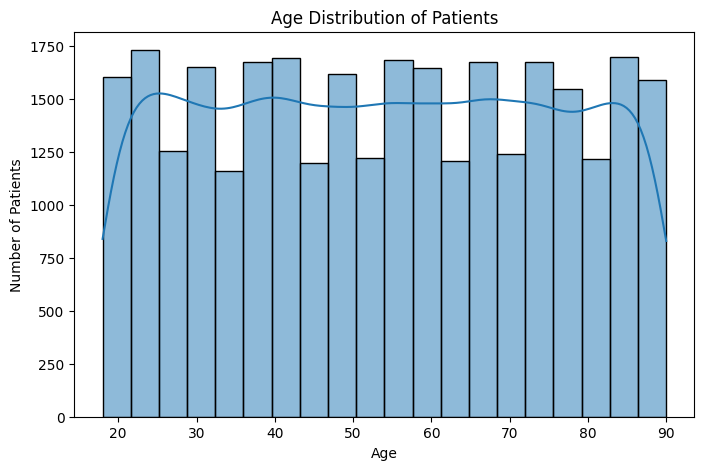

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [19]:
df["gender"].value_counts()

,count
gender,
Male,10097
Other,10024
Female,9879


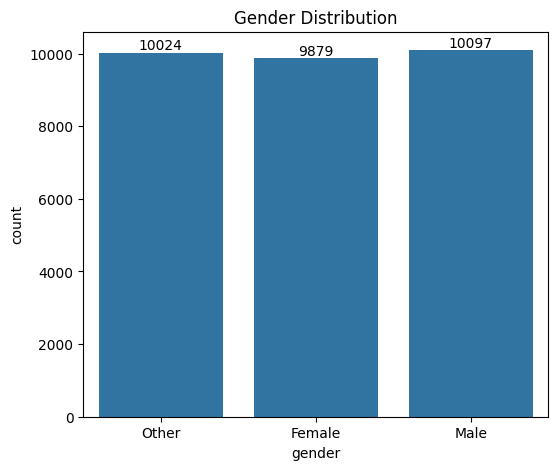

In [20]:
plt.figure(figsize=(6,5))

ax=sns.countplot(x="gender", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")

plt.show()

In [21]:
df["readmitted_30_days"].value_counts()

,count
readmitted_30_days,
No,26326
Yes,3674


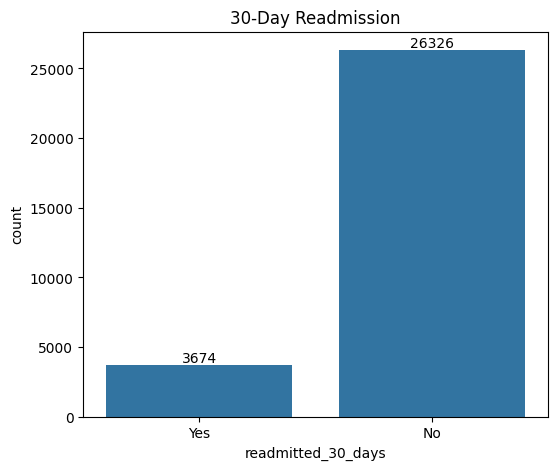

In [22]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x="readmitted_30_days", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("30-Day Readmission")

plt.show()

In [23]:
print("Average day Stay :")

df["length_of_stay"].mean()

Average day Stay :


np.float64(5.5029)

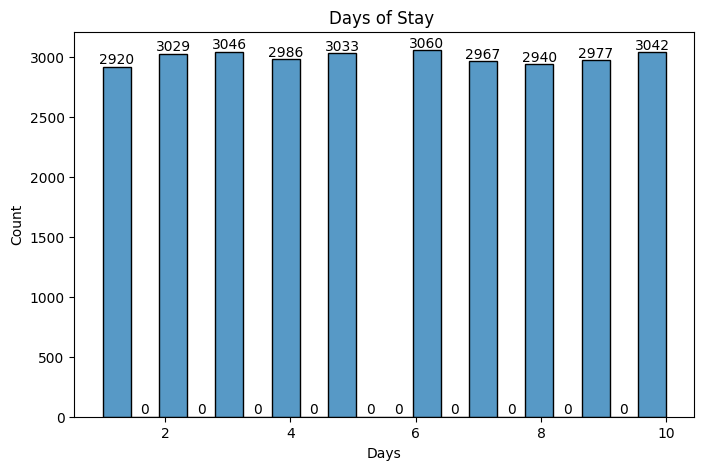

In [24]:
plt.figure(figsize=(8,5))

ax=sns.histplot(df["length_of_stay"], bins=20)

for container in ax.containers:
    ax.bar_label(container)


plt.title("Days of Stay ")

plt.xlabel("Days")

plt.show()

In [25]:
readmission_gender = pd.crosstab(df["gender"], df["readmitted_30_days"])

readmission_gender

readmitted_30_days,No,Yes
gender,,
Female,8682,1197
Male,8856,1241
Other,8788,1236


<Figure size 700x500 with 0 Axes>

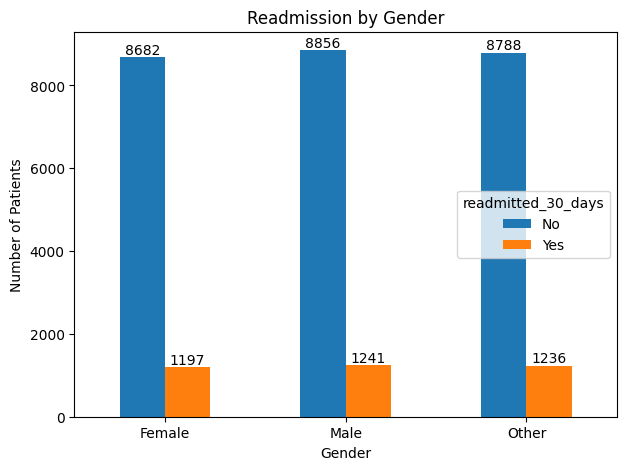

In [26]:
plt.figure(figsize=(7,5))

ax = readmission_gender.plot(kind="bar", figsize=(7,5))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [27]:
diabetes_readmission = pd.crosstab(df["diabetes"], df["readmitted_30_days"])

diabetes_readmission

readmitted_30_days,No,Yes
diabetes,,
No,13353,1698
Yes,12973,1976


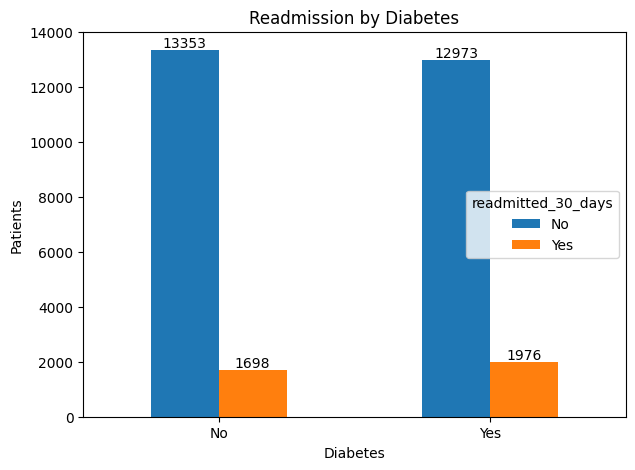

In [28]:
ax = diabetes_readmission.plot(kind="bar", figsize=(7,5))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Readmission by Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Patients")

plt.xticks(rotation=0)

plt.show()

In [29]:
hypertension_readmission = pd.crosstab(df["hypertension"], df["readmitted_30_days"])

hypertension_readmission

readmitted_30_days,No,Yes
hypertension,,
No,13293,1729
Yes,13033,1945


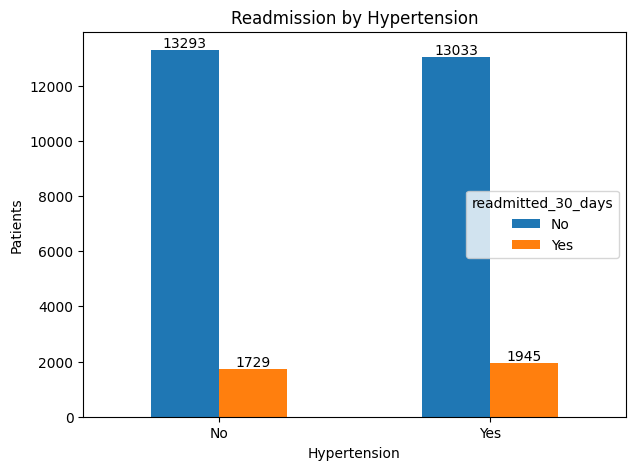

In [30]:
ax = hypertension_readmission.plot(kind="bar", figsize=(7,5))

for container in ax.containers:
    ax.bar_label(container)

plt.title("Readmission by Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Patients")

plt.xticks(rotation=0)

plt.show()

In [31]:
df["bmi"].describe()

,bmi
count,30000.000000
mean,28.946263
std,6.348204
min,18.000000
25%,23.400000
50%,28.900000
75%,34.500000
max,40.000000


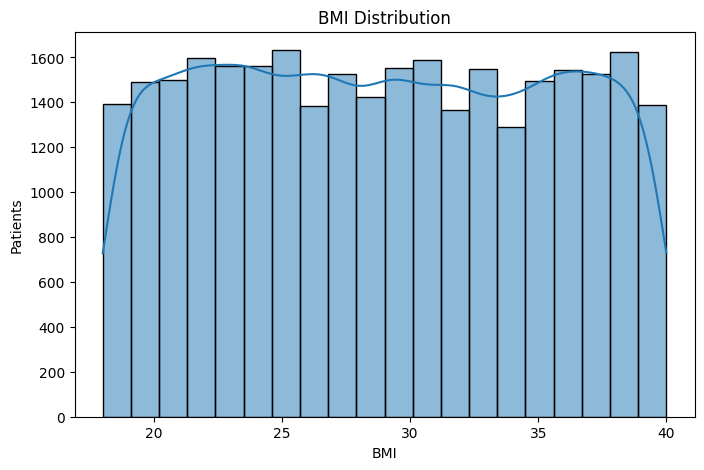

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["bmi"], bins=20, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Patients")

plt.show()

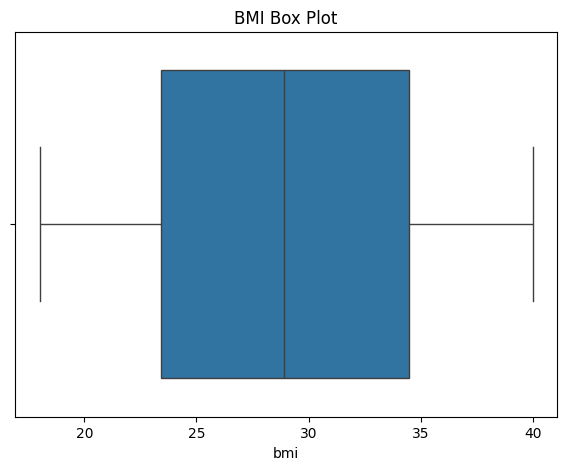

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df["bmi"])

plt.title("BMI Box Plot")

plt.show()

In [34]:
df["cholesterol"].describe()

,cholesterol
count,30000.000000
mean,225.260400
std,43.585671
min,150.000000
25%,188.000000
50%,225.000000
75%,263.000000
max,300.000000


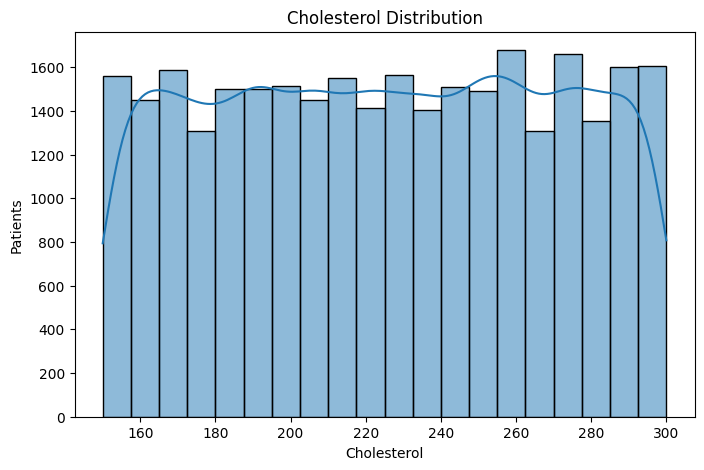

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Patients")

plt.show()

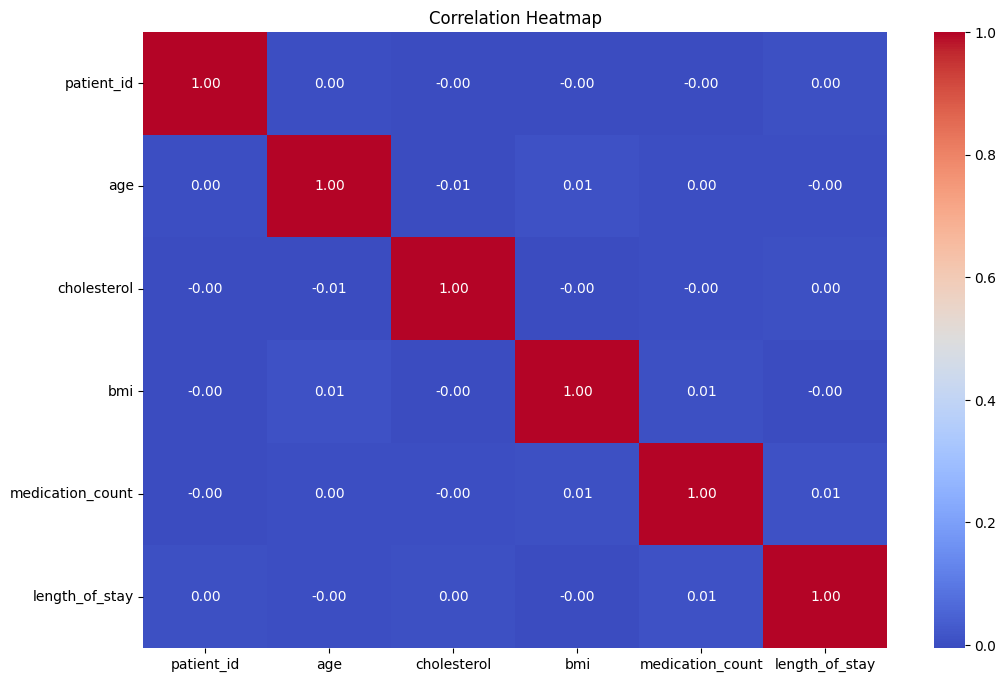

In [36]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [37]:
risk = df.groupby("readmitted_30_days")[["age","bmi","cholesterol","length_of_stay"]].mean()

risk

,age,bmi,cholesterol,length_of_stay
readmitted_30_days,,,,
No,53.880802,28.978212,225.195548,5.510028
Yes,53.908819,28.717338,225.725095,5.451824


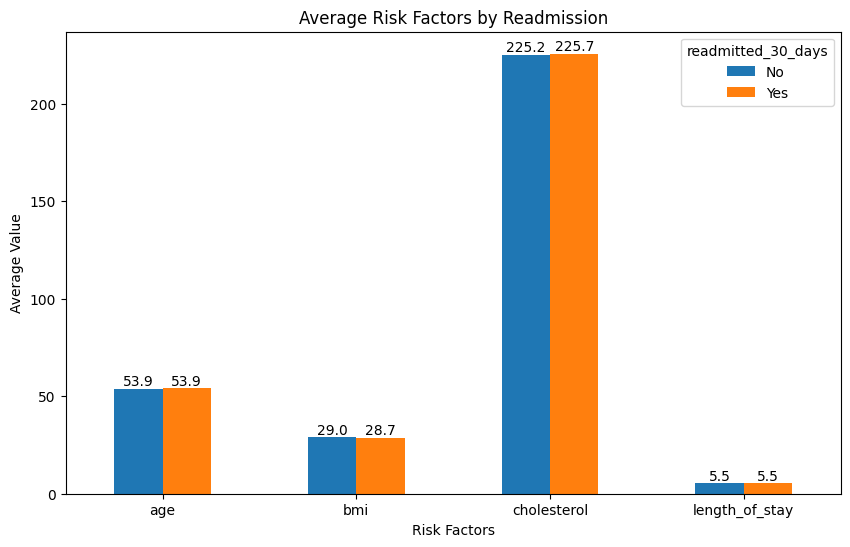

In [38]:
ax = risk.T.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Average Risk Factors by Readmission")
plt.xlabel("Risk Factors")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

In [39]:
# Create Age Groups

df["age_group"] = pd.cut(df["age"],
                         bins=[0,18,35,50,65,100],
                         labels=["0-18","19-35","36-50","51-65","65+"])

df["age_group"].value_counts()

,count
age_group,
65+,10244
19-35,7034
36-50,6186
51-65,6162
0-18,374


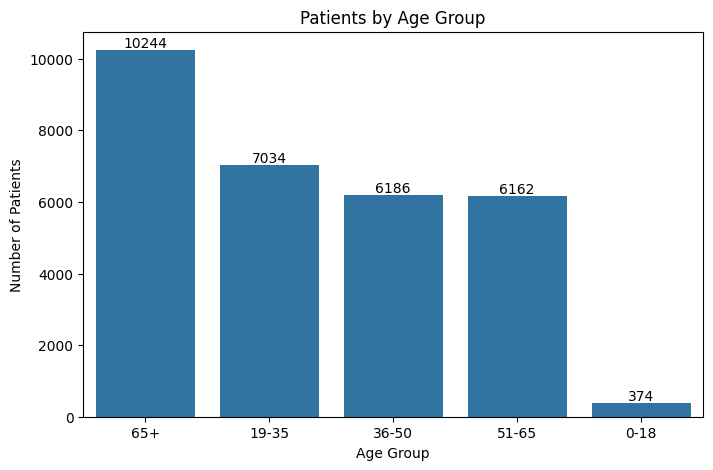

In [40]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x="age_group",
                   data=df,
                   order=df["age_group"].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

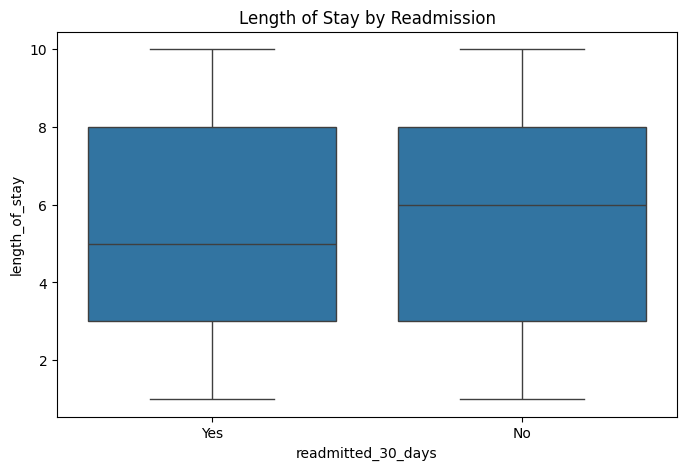

In [41]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x="readmitted_30_days",
                 y="length_of_stay",
                 data=df)

plt.title("Length of Stay by Readmission")

plt.show()

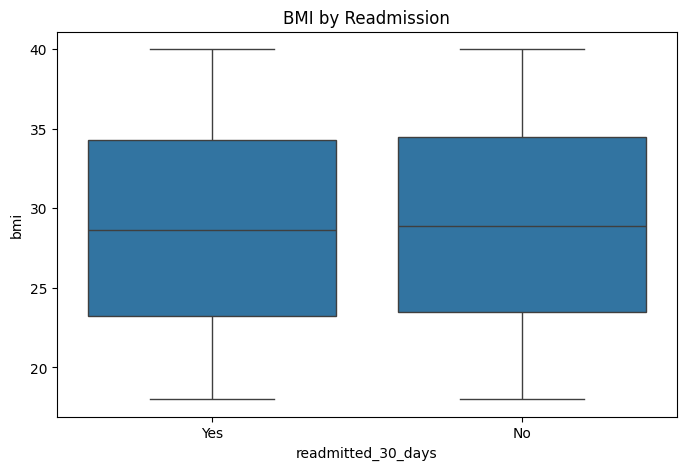

In [42]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x="readmitted_30_days",
                 y="bmi",
                 data=df)

plt.title("BMI by Readmission")

plt.show()

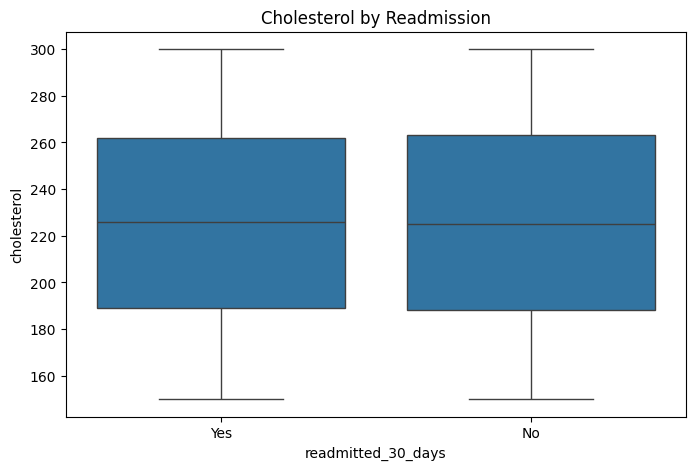

In [43]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x="readmitted_30_days",
                 y="cholesterol",
                 data=df)

plt.title("Cholesterol by Readmission")

plt.show()

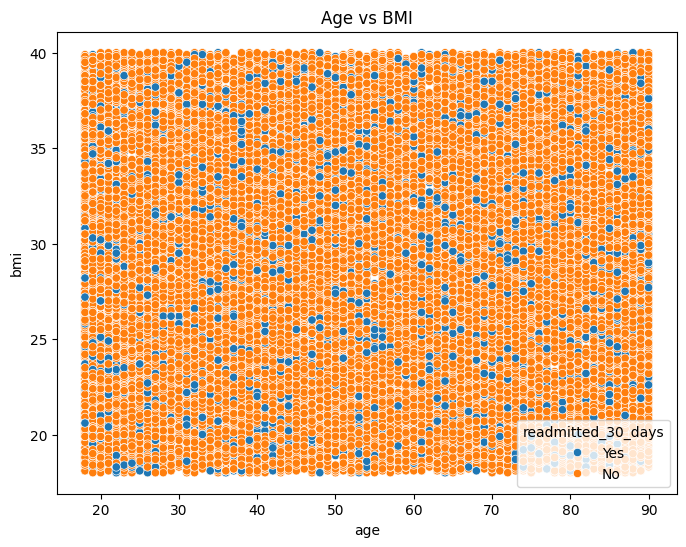

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="age",
                y="bmi",
                hue="readmitted_30_days",
                data=df)

plt.title("Age vs BMI")

plt.show()

In [45]:
summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

summary

,Missing Values,Unique Values,Data Type
patient_id,0,30000,int64
age,0,73,int64
gender,0,3,object
blood_pressure,0,1581,object
cholesterol,0,151,int64
bmi,0,221,float64
diabetes,0,2,object
hypertension,0,2,object
medication_count,0,11,int64
length_of_stay,0,10,int64


In [46]:
# KPIs

total_patients = len(df)

readmitted = (df["readmitted_30_days"]=="Yes").sum()

readmission_rate = (readmitted/total_patients)*100

avg_age = df["age"].mean()

avg_stay = df["length_of_stay"].mean()

print("Total Patients :", total_patients)
print("Readmission Rate :", round(readmission_rate,2),"%")
print("Average Age :", round(avg_age,2))
print("Average Stay :", round(avg_stay,2))

Total Patients : 30000
Readmission Rate : 12.25 %
Average Age : 53.88
Average Stay : 5.5


In [48]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days', 'age_group']


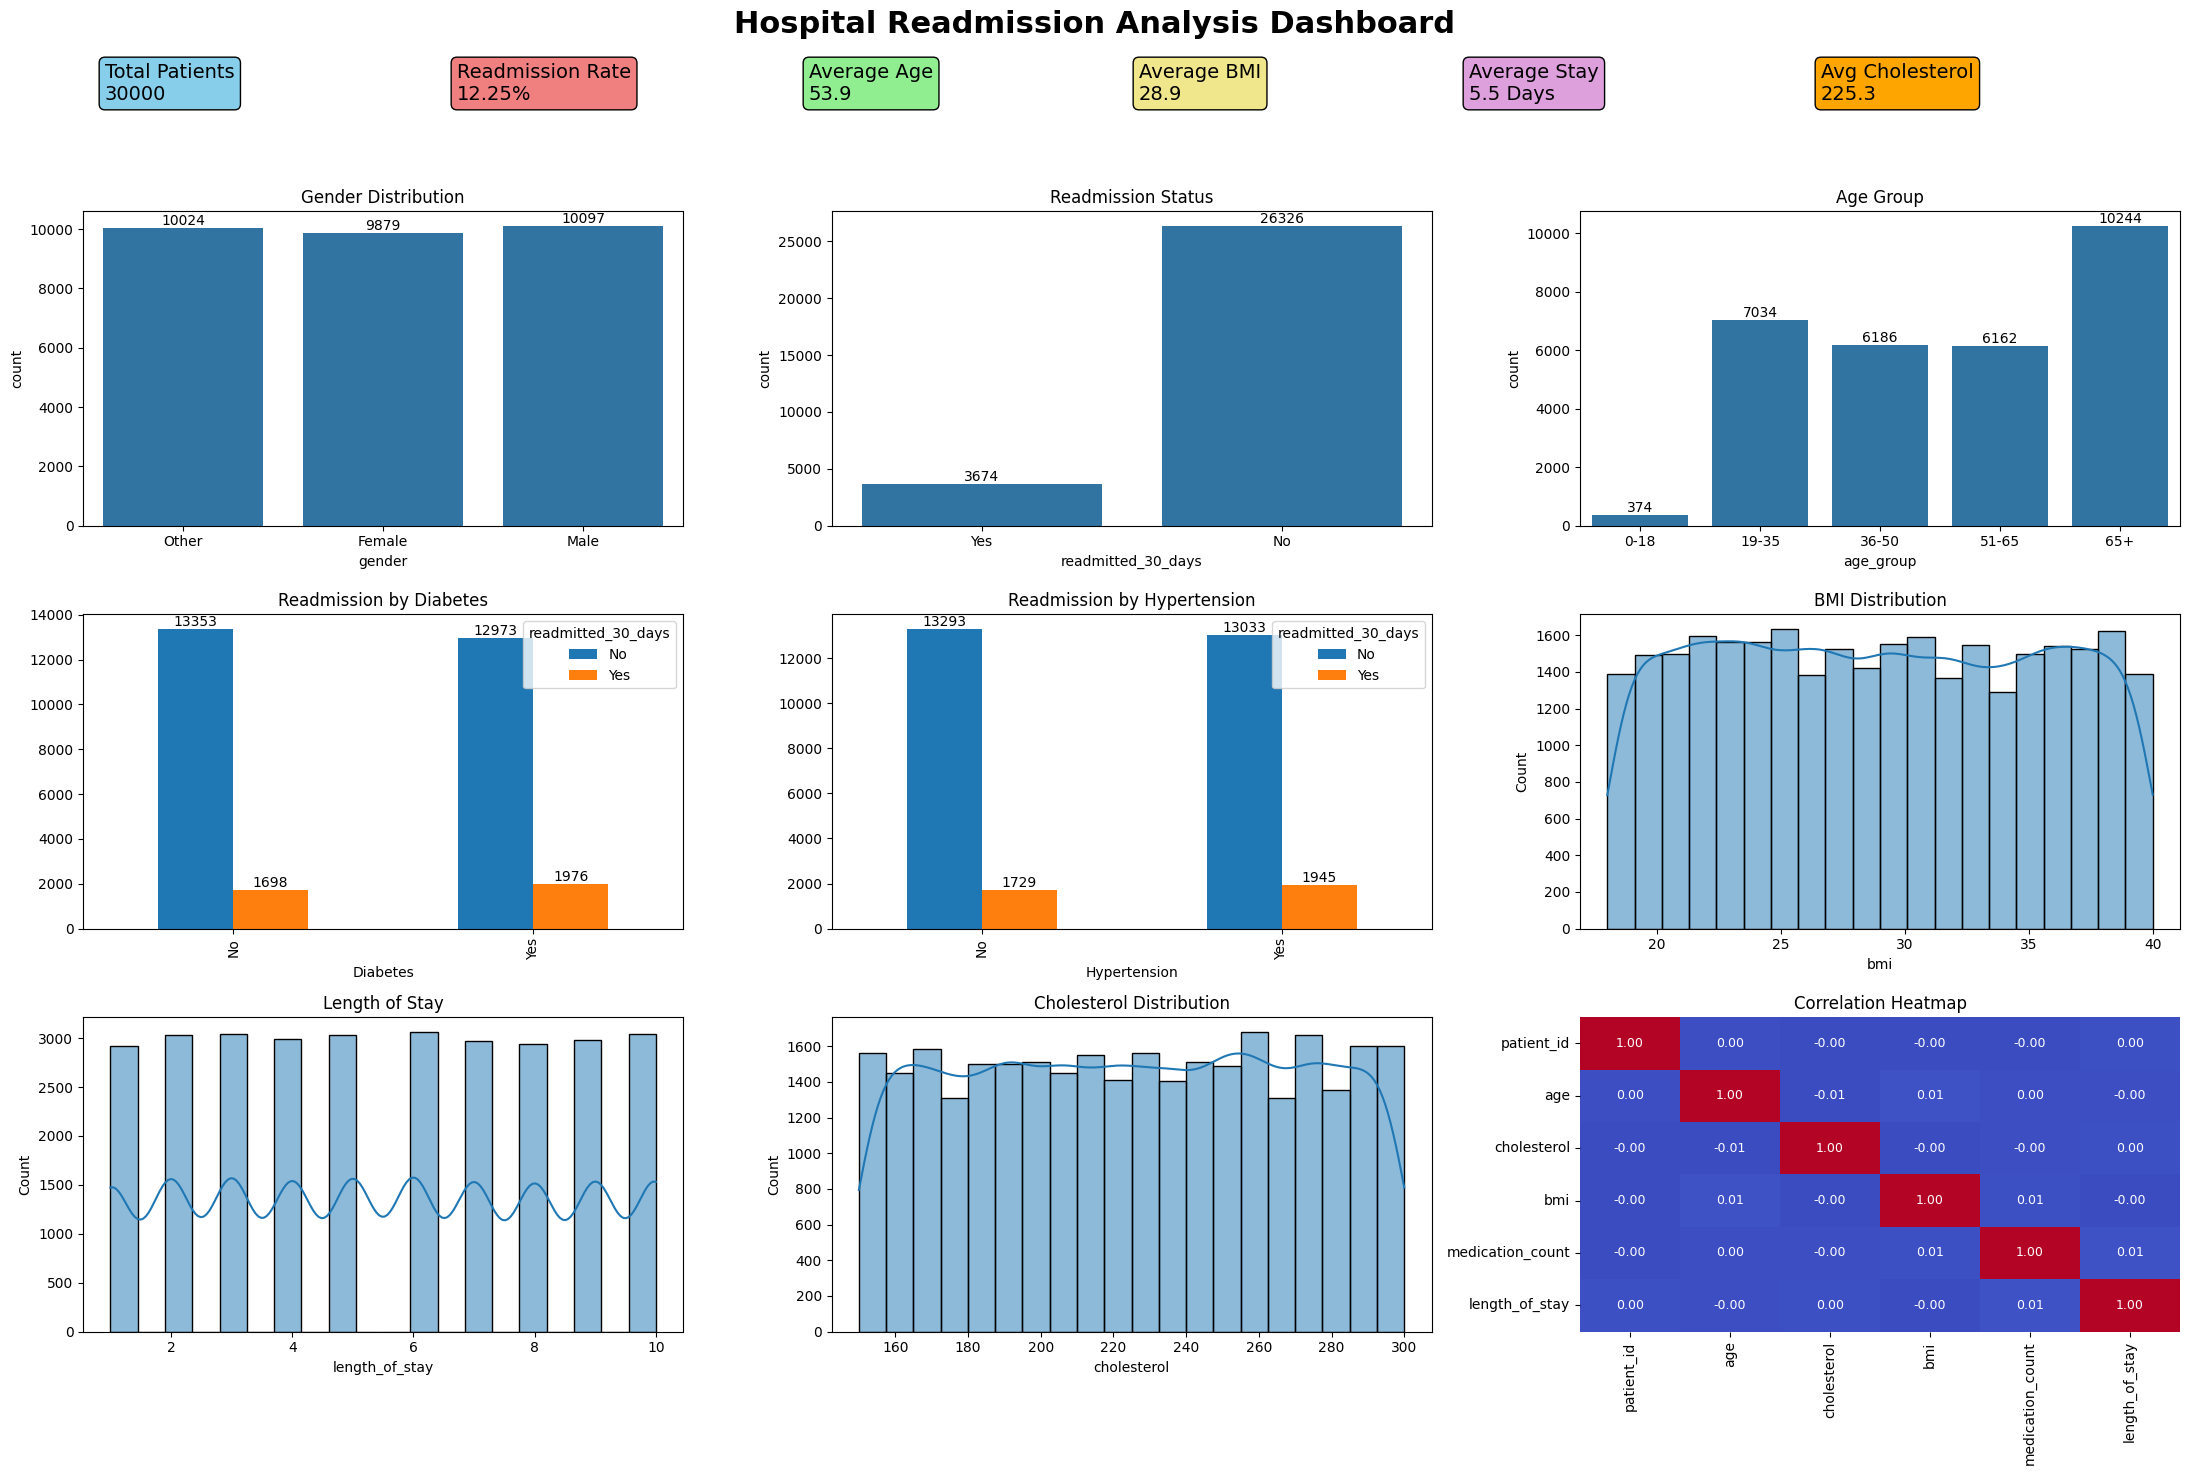

In [53]:


# ============================
# HOSPITAL READMISSION DASHBOARD
# ============================

# KPI Values
total_patients = len(df)
readmission_rate = (df["readmitted_30_days"] == "Yes").mean() * 100
avg_age = df["age"].mean()
avg_bmi = df["bmi"].mean()
avg_chol = df["cholesterol"].mean()
avg_stay = df["length_of_stay"].mean()

# Dashboard Layout Setup
fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    "Hospital Readmission Analysis Dashboard", fontsize=22, fontweight="bold"
)

# =========================================
# KPI CARDS
# =========================================
fig.text(
    0.05,
    0.92,
    f"Total Patients\n{total_patients}",
    fontsize=14,
    bbox=dict(facecolor="skyblue", edgecolor="black", boxstyle="round"),
)
fig.text(
    0.21,
    0.92,
    f"Readmission Rate\n{readmission_rate:.2f}%",
    fontsize=14,
    bbox=dict(facecolor="lightcoral", edgecolor="black", boxstyle="round"),
)
fig.text(
    0.37,
    0.92,
    f"Average Age\n{avg_age:.1f}",
    fontsize=14,
    bbox=dict(facecolor="lightgreen", edgecolor="black", boxstyle="round"),
)
fig.text(
    0.52,
    0.92,
    f"Average BMI\n{avg_bmi:.1f}",
    fontsize=14,
    bbox=dict(facecolor="khaki", edgecolor="black", boxstyle="round"),
)
fig.text(
    0.67,
    0.92,
    f"Average Stay\n{avg_stay:.1f} Days",
    fontsize=14,
    bbox=dict(facecolor="plum", edgecolor="black", boxstyle="round"),
)
fig.text(
    0.83,
    0.92,
    f"Avg Cholesterol\n{avg_chol:.1f}",
    fontsize=14,
    bbox=dict(facecolor="orange", edgecolor="black", boxstyle="round"),
)

# =========================================
# 1. Gender Distribution
# =========================================
plt.subplot(3, 3, 1)
ax = sns.countplot(data=df, x="gender")
for c in ax.containers:
    ax.bar_label(c)
plt.title("Gender Distribution")

# =========================================
# 2. Readmission Status
# =========================================
plt.subplot(3, 3, 2)
ax = sns.countplot(data=df, x="readmitted_30_days")
for c in ax.containers:
    ax.bar_label(c)
plt.title("Readmission Status")

# =========================================
# 3. Age Group
# =========================================
plt.subplot(3, 3, 3)
ax = sns.countplot(data=df, x="age_group")
for c in ax.containers:
    ax.bar_label(c)
plt.title("Age Group")

# =========================================
# 4. Diabetes vs Readmission (Fixed Plotting)
# =========================================
plt.subplot(3, 3, 4)
dia = pd.crosstab(df["diabetes"], df["readmitted_30_days"])
ax = dia.plot(kind="bar", ax=plt.gca())  # ax=plt.gca() जोड़ा गया है
for c in ax.containers:
    ax.bar_label(c)
plt.title("Readmission by Diabetes")
plt.xlabel("Diabetes")

# =========================================
# 5. Hypertension vs Readmission (Fixed Plotting)
# =========================================
plt.subplot(3, 3, 5)
hyp = pd.crosstab(df["hypertension"], df["readmitted_30_days"])
ax = hyp.plot(kind="bar", ax=plt.gca())  # ax=plt.gca() जोड़ा गया है
for c in ax.containers:
    ax.bar_label(c)
plt.title("Readmission by Hypertension")
plt.xlabel("Hypertension")

# =========================================
# 6. BMI Distribution
# =========================================
plt.subplot(3, 3, 6)
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")

# =========================================
# 7. Length of Stay
# =========================================
plt.subplot(3, 3, 7)
sns.histplot(df["length_of_stay"], bins=20, kde=True)
plt.title("Length of Stay")

# =========================================
# 8. Cholesterol Distribution
# =========================================
plt.subplot(3, 3, 8)
sns.histplot(df["cholesterol"], bins=20, kde=True)
plt.title("Cholesterol Distribution")

# =========================================
# 9. Correlation Heatmap
# =========================================
plt.subplot(3, 3, 9)
corr = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(
    corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=False, annot_kws={"size": 9}
)
plt.title("Correlation Heatmap")

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()